In [1]:
import pandas as pd

df = pd.read_csv("../datos.xls", header=0)
df.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend


A priori vemos datos duplicados.

In [5]:
df.dtypes

Transaction        int64
Item                 str
date_time            str
period_day           str
weekday_weekend      str
dtype: object

In [8]:
df.shape

(20507, 5)

In [22]:
df.dropna().shape

(20507, 5)

In [2]:
df.drop_duplicates().shape

(18887, 5)

Vemos que no hay valores nulos a priori, pero si que hay valores duplicados.

In [3]:
df = df.drop_duplicates()

for col in ["Item", "period_day", "weekday_weekend"]:
    print(f"Number of unique instances in col {col}:", df[col].nunique())

Number of unique instances in col Item: 94
Number of unique instances in col period_day: 4
Number of unique instances in col weekday_weekend: 2


In [4]:
for col in ["period_day", "weekday_weekend"]:
    print(df[col].value_counts(), end="\n\n")

period_day
afternoon    10687
morning       7697
evening        490
night           13
Name: count, dtype: int64

weekday_weekend
weekday    11830
weekend     7057
Name: count, dtype: int64



Vemos también que el `weekday_weekend` es básicamente booleana, y que `period_day` podría ser interpretada como una categórica ordinal, donde el orden es dado por el tiempo. También vemos que hay 94 distintos productos, lo que tiene sentido viniendo de una base de datos tan grande. 

Vamos a explorar más esa columna. 

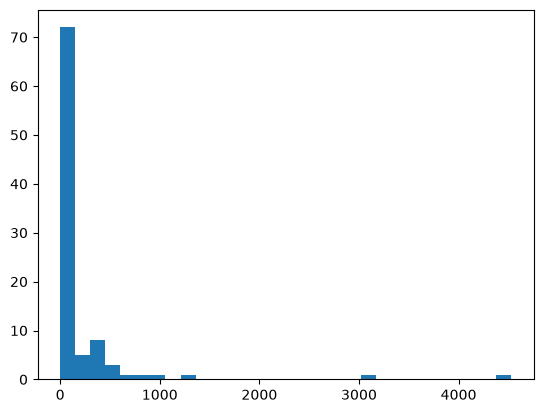

In [5]:
from matplotlib import pyplot as plt

data = df["Item"].value_counts(ascending=True)
plt.figure()
plt.hist(data, bins=30)
plt.show()

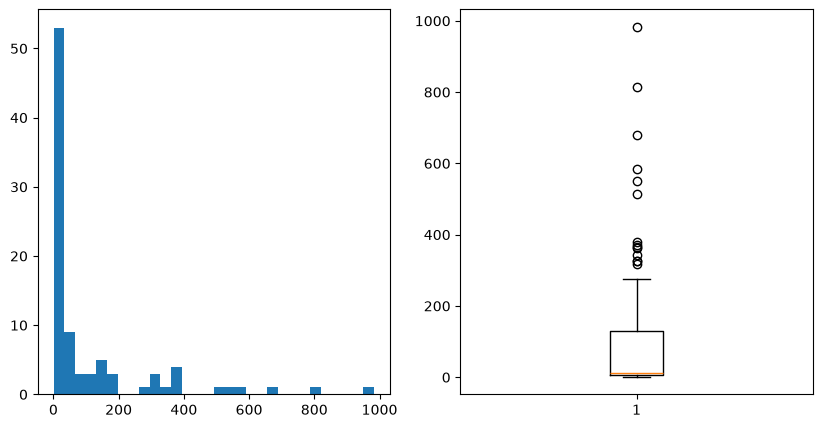

In [6]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(data[:-3], bins=30)
plt.subplot(1, 2, 2)
plt.boxplot(data[:-3])
plt.show()

In [50]:
print(data.agg(["mean", "median", "std"]), end="\n\n")
print(data.mode())

mean      218.159574
median     15.000000
std       682.878463
Name: count, dtype: float64

0    1
Name: count, dtype: int64


Podemos ver que hay pocos artículos que son comprados muchas veces. También podemos ver que la mayoría de los productos son comprados una sola vez, por lo que no tiene mucho sentido usar la media. La mediana es 15. 

Veamos ahora los nulos. Tenemos que ver solamente los de `Item` y `date_time`, ya que de `period_day` y `weekday_weekend` sabemos que no hay por los `value_counts`. 

In [12]:
cols = ["Item", "date_time"]
placeholders = ["none", "nulo", "nan"]
mask = df[cols].apply(lambda s: s.str.lower().str.strip()).isin(placeholders)
print(mask.sum())
print(mask.any())

Item         0
date_time    0
dtype: int64
Item         False
date_time    False
dtype: bool


In [15]:
data = df["Item"].value_counts()
data[data >= 100]

Item
Coffee               4528
Bread                3097
Tea                  1350
Cake                  983
Pastry                815
Sandwich              680
Medialuna             585
Hot chocolate         552
Cookies               515
Brownie               379
Farm House            371
Juice                 365
Muffin                364
Alfajores             344
Scone                 327
Soup                  326
Toast                 318
Scandinavian          275
Truffles              192
Coke                  184
Spanish Brunch        172
Baguette              152
Tiffin                146
Jam                   142
Fudge                 142
Mineral water         134
Jammie Dodgers        125
Chicken Stew          123
Hearty & Seasonal     100
Name: count, dtype: int64

In [23]:
data = df["date_time"].value_counts()
print(data)
print(data.agg(["min", "max", "mean", "std"]))

date_time
05-04-2017 17:22    10
22-12-2016 13:32     9
12-02-2017 14:35     9
17-02-2017 14:18     9
26-03-2017 10:13     9
                    ..
09-04-2017 12:22     1
09-04-2017 12:28     1
09-04-2017 13:04     1
09-04-2017 14:24     1
09-04-2017 15:04     1
Name: count, Length: 9182, dtype: int64
min      1.000000
max     10.000000
mean     2.056959
std      1.173873
Name: count, dtype: float64


In [22]:
datetime = pd.to_datetime(df["date_time"], format="%d-%m-%Y %H:%M")
datetime.agg(["min", "max"])

min   2016-10-30 09:58:00
max   2017-04-09 15:04:00
Name: date_time, dtype: datetime64[us]

vemos que a simple vista no hay ningún valor placeholder para nulos en Items ni date_time. A datetime, vemos que los valores mínimo y máximo son completamente normales, y están muy bien distribuidos los value_counts, así que no hay una concentración que nos indique que tal vez es un placeholder. 

Conclusión: no nulos. 